# Assignment 4 - Classification

## Customer Churn Prediction using Classification Algorithms

This notebook demonstrates the implementation of classification algorithms for predicting customer churn using the IBM Telco Customer Churn dataset.

In [1]:
# Import necessary libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

## Setup the Environment

In [2]:
# Import os library

import os

In [3]:
# Change the working directory

os.chdir(r"C:\Users\ASHMIT\Downloads")

In [4]:
# Check the current working directory

os.getcwd()

'C:\\Users\\ASHMIT\\Downloads'

## Loading the Data

In [5]:
# Load the dataset

df = pd.read_csv(r"C:\Users\ASHMIT\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [6]:
# Display the first five rows

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploratory Data Analysis (EDA)


In [7]:
# Display the last five rows

df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
# Display descriptive statistics

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
# Display descriptive statistics for categorical variables

df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [10]:
# Display column names

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
# Check missing values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
# Check duplicate values

df.duplicated().sum()

np.int64(0)

In [13]:
# Correlation matrix for numerical variables

df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


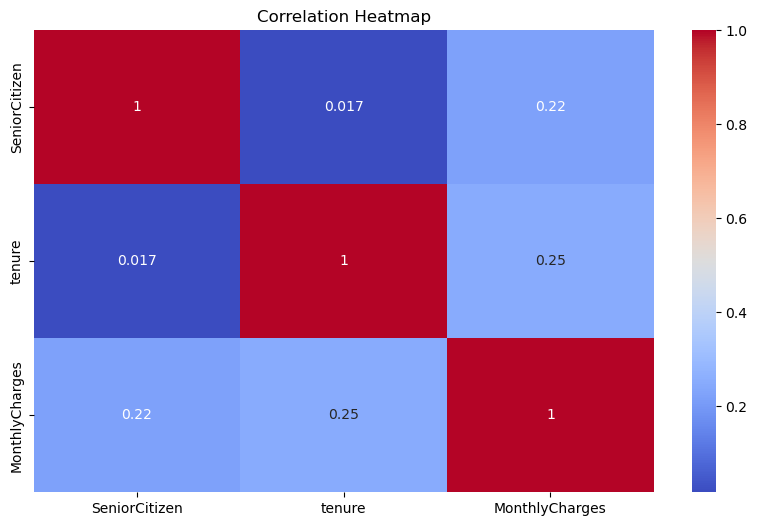

In [14]:
# Plot the correlation heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

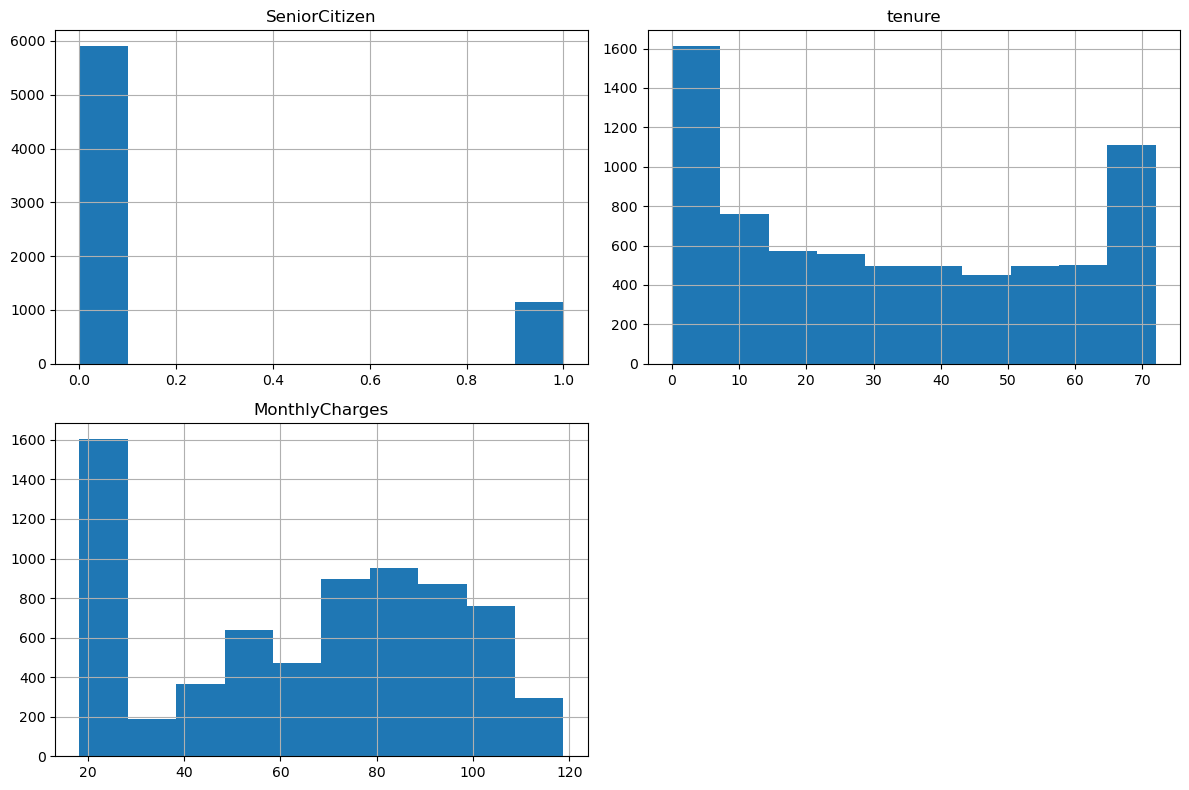

In [15]:
# Plot histograms

df.hist(figsize=(12,8))

plt.tight_layout()

plt.show()

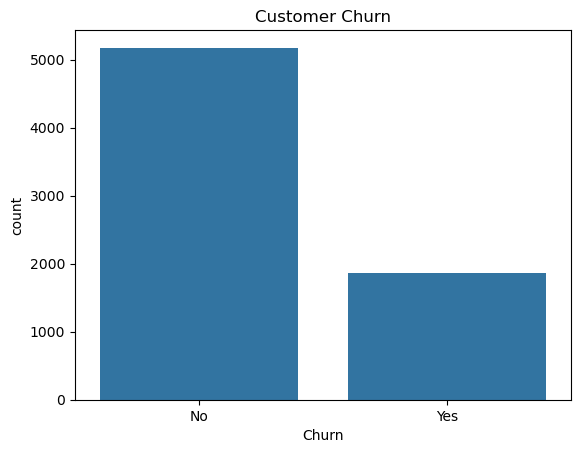

In [16]:
# Plot the target variable

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn")

plt.show()

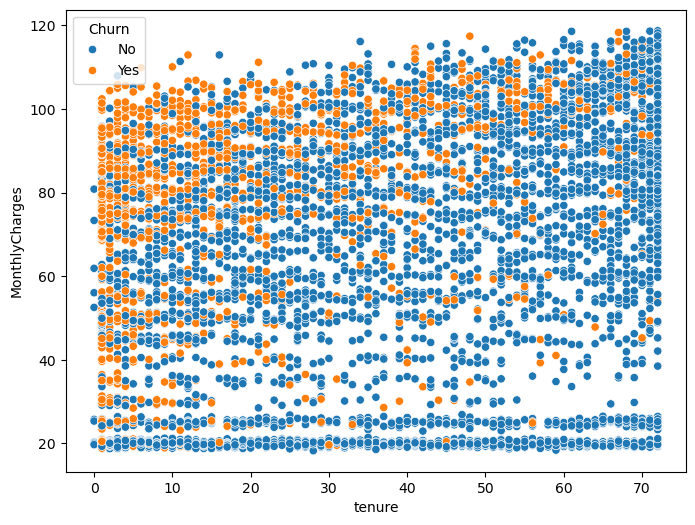

In [17]:
# Scatter plot

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    data=df
)

plt.show()

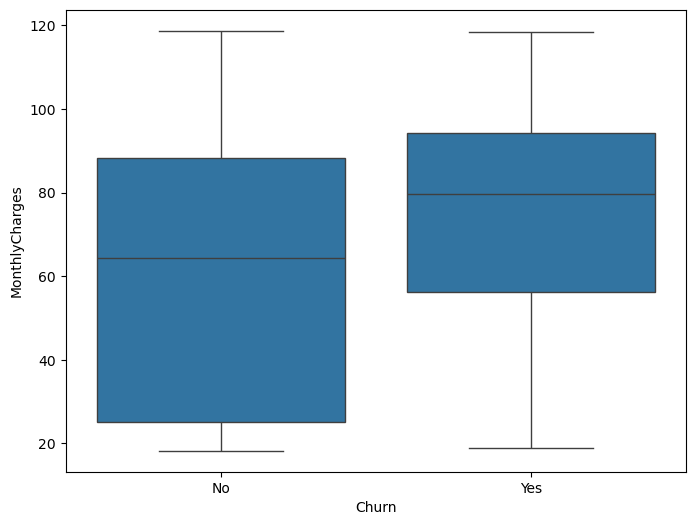

In [18]:
# Box plot

plt.figure(figsize=(8,6))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.show()

### Data Preprocessing


In [19]:
# Remove the customerID column

df = df.drop("customerID", axis=1)

In [20]:
# Display the first five rows

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Convert Target Variable into Numeric

In [21]:
# Convert target variable into numeric values

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [22]:
# Display the target variable

df["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

### Create Dummy Variables

In [23]:
# Convert categorical variables into dummy variables

df = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

In [24]:
# Display the first five rows

df.head()

,SeniorCitizen,tenure,MonthlyCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,1,29.85,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,34,56.95,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,2,53.85,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,45,42.30,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,2,70.70,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


### Select Independent and Dependent Variables

In [25]:
# Select independent variables

X = df.drop("Churn", axis=1)

In [26]:
# Select dependent variable

y = df["Churn"]

In [27]:
# Display the independent variables

X.head()

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,1,29.85,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,34,56.95,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,2,53.85,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,45,42.30,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,2,70.70,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [28]:
# Display the dependent variable

y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

### Train-Test Split

In [29]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [30]:
# Display the shape of training and testing data

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (5634, 6559)
X_test : (1409, 6559)
y_train : (5634,)
y_test : (1409,)


### Logistic Regression


#### Build the Logistic Regression Model

In [31]:
# Create the Logistic Regression model

logistic_model = LogisticRegression()

In [32]:
# Train the Logistic Regression model

logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### Prediction

In [33]:
# Predict the target values

y_pred = logistic_model.predict(X_test)

In [34]:
# Display the first 10 predicted values

print(y_pred[:10])

[1 0 0 1 0 0 0 0 0 0]


#### Model Evaluation

In [35]:
# Calculate Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8105039034776437


In [36]:
# Calculate Precision

precision = precision_score(y_test, y_pred)

print("Precision :", precision)

Precision : 0.6596385542168675


In [37]:
# Calculate Recall

recall = recall_score(y_test, y_pred)

print("Recall :", recall)

Recall : 0.5871313672922251


In [38]:
# Calculate F1-Score

f1 = f1_score(y_test, y_pred)

print("F1-Score :", f1)

F1-Score : 0.6212765957446809


In [39]:
# Calculate ROC-AUC Score

roc_auc = roc_auc_score(y_test, y_pred)

print("ROC-AUC :", roc_auc)

ROC-AUC : 0.7390290041094331


#### Confusion Matrix

In [40]:
# Display the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[923 113]
 [154 219]]


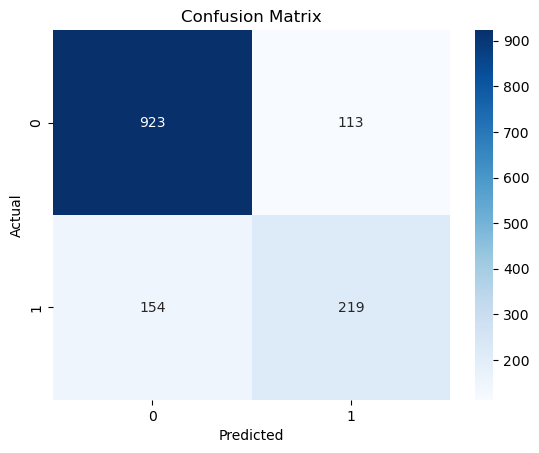

In [41]:
# Plot the confusion matrix

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

### Decision Tree Classification


#### Build the Decision Tree Model

In [42]:
# Create the Decision Tree model

decision_tree = DecisionTreeClassifier(random_state=42)

In [43]:
# Train the Decision Tree model

decision_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Prediction

In [44]:
# Predict the target values

y_pred_tree = decision_tree.predict(X_test)

In [45]:
# Display the first 10 predicted values

print(y_pred_tree[:10])

[1 0 0 1 0 0 0 0 0 1]


#### Model Evaluation

In [46]:
# Calculate Accuracy

accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Accuracy :", accuracy_tree)

Accuracy : 0.772888573456352


In [47]:
# Calculate Precision

precision_tree = precision_score(y_test, y_pred_tree)

print("Precision :", precision_tree)

Precision : 0.5874587458745875


In [48]:
# Calculate Recall

recall_tree = recall_score(y_test, y_pred_tree)

print("Recall :", recall_tree)

Recall : 0.4772117962466488


In [49]:
# Calculate F1-Score

f1_tree = f1_score(y_test, y_pred_tree)

print("F1-Score :", f1_tree)

F1-Score : 0.5266272189349113


In [50]:
# Calculate ROC-AUC Score

roc_auc_tree = roc_auc_score(y_test, y_pred_tree)

print("ROC-AUC :", roc_auc_tree)

ROC-AUC : 0.6782777127951389


#### Confusion Matrix

In [51]:
# Display the confusion matrix

cm_tree = confusion_matrix(y_test, y_pred_tree)

print(cm_tree)

[[911 125]
 [195 178]]


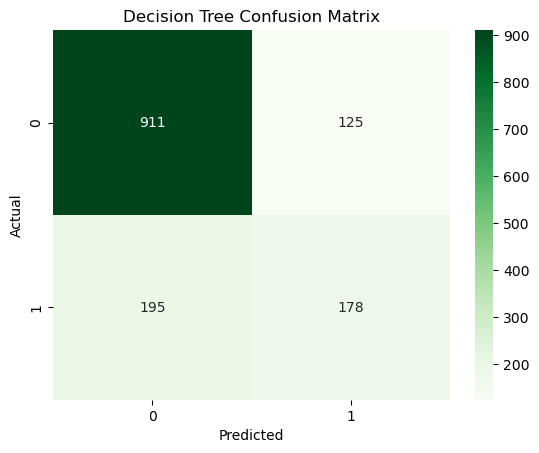

In [52]:
# Plot the confusion matrix

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Decision Tree Confusion Matrix")

plt.show()

#### Important Variables

In [53]:
# Display feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.217152
2,MonthlyCharges,0.124940
9,InternetService_Fiber optic,0.103833
27,PaymentMethod_Electronic check,0.016720
25,PaperlessBilling_Yes,0.015394
0,SeniorCitizen,0.015318
4,Partner_Yes,0.014975
23,Contract_One year,0.010947
18,TechSupport_Yes,0.009162
3,gender_Male,0.008917


#### ROC Curve

In [54]:
# Calculate ROC Curve

y_prob = logistic_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

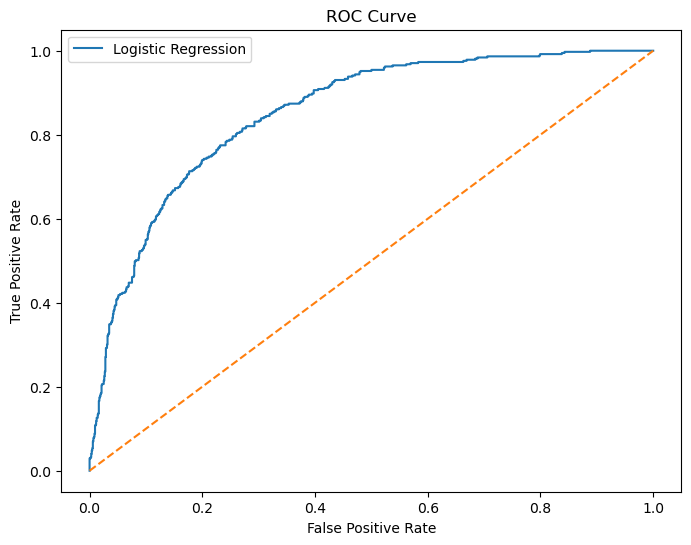

In [55]:
# Plot the ROC Curve

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

#### Threshold Comparison

In [56]:
# Compare different classification thresholds

thresholds = [0.3, 0.5, 0.7]

for threshold in thresholds:

    predictions = (y_prob >= threshold).astype(int)

    print("Threshold :", threshold)
    print("Accuracy :", accuracy_score(y_test, predictions))
    print("Precision :", precision_score(y_test, predictions))
    print("Recall :", recall_score(y_test, predictions))
    print("F1-Score :", f1_score(y_test, predictions))
    print("-" * 40)

Threshold : 0.3
Accuracy : 0.7579843860894251
Precision : 0.5284697508896797
Recall : 0.7962466487935657
F1-Score : 0.6352941176470588
----------------------------------------
Threshold : 0.5
Accuracy : 0.8105039034776437
Precision : 0.6596385542168675
Recall : 0.5871313672922251
F1-Score : 0.6212765957446809
----------------------------------------
Threshold : 0.7
Accuracy : 0.772888573456352
Precision : 0.7731958762886598
Recall : 0.20107238605898123
F1-Score : 0.3191489361702128
----------------------------------------


### Interpretation

The classification models are evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and the Confusion Matrix.

The model with better evaluation metrics is considered more suitable for predicting customer churn.